## Fitting the SEIR model to real UK COVID data

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.integrate import odeint
from scipy.optimize import curve_fit 
print("complete")

complete


In [11]:
df =pd.read_csv('../data/owid-covid-data.csv')

df_uk = df[df['location'] == 'United Kingdom']
df_uk['date'] = pd.to_datetime(df_uk['date'])
df_uk = df_uk[df_uk['date'].dt.year == 2020]
df_uk = df_uk.dropna(subset=['new_cases_smoothed'])

print(df_uk.shape)



(357, 67)


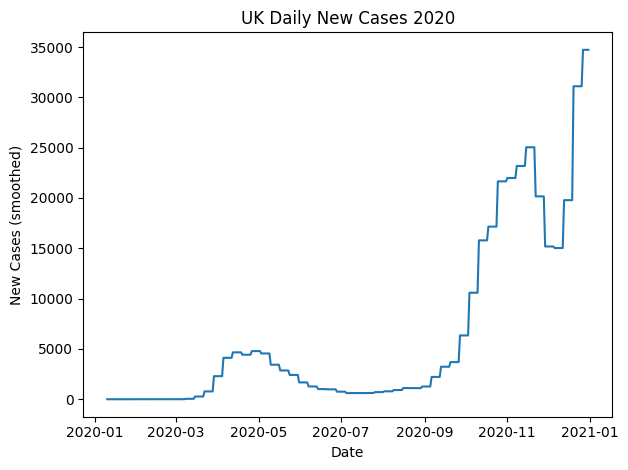

In [20]:
# plot raw data 
plt.plot(df_uk['date'], df_uk['new_cases_smoothed'])
plt.title('UK Daily New Cases 2020')
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.tight_layout()
plt.show()

Wave 1 data: 122 days


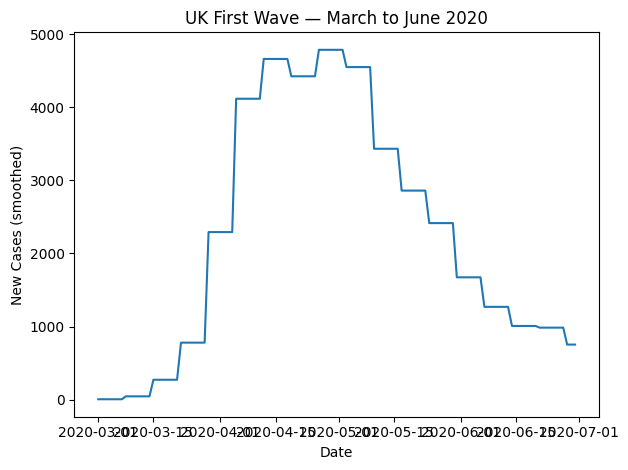

In [21]:
wave1 = df_uk[(df_uk['date'] >= '2020-03-01') & (df_uk['date'] <= '2020-06-30')]
wave1 = wave1.reset_index(drop=True)

print(f'Wave 1 data: {len(wave1)} days')

plt.plot(wave1['date'], wave1['new_cases_smoothed'])
plt.title('UK First Wave — March to June 2020')
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.tight_layout()
plt.show()

In [22]:
N = 67000000
I0 = 10
E0 = 100
R0_init = 0
S0 = N - I0 - E0 - R0_init

t_fit = np.arange(len(wave1))
actual_cases = wave1['new_cases_smoothed'].values

def seir_for_fitting(t, beta, gamma):
    sigma = 0.2  # fixed incubation rate
    
    S, E, I, R = S0, E0, I0, R0_init
    new_cases = []
    
    for _ in t:
        new_infections = beta * S * I / N
        dS = -new_infections
        dE = new_infections - sigma * E
        dI = sigma * E - gamma * I
        dR = gamma * I
        
        S += dS
        E += dE
        I += dI
        R += dR
        
        new_cases.append(new_infections)
    
    return np.array(new_cases)

# Fit the model
params, _ = curve_fit(seir_for_fitting, t_fit, actual_cases, 
                       p0=[0.3, 0.1],  # initial guesses
                       bounds=([0, 0], [1, 1]))  # parameter bounds

beta_fit, gamma_fit = params
print(f'Fitted beta: {beta_fit:.4f}')
print(f'Fitted gamma: {gamma_fit:.4f}')
print(f'Fitted R0: {beta_fit/gamma_fit:.2f}')

Fitted beta: 1.0000
Fitted gamma: 0.7897
Fitted R0: 1.27


### Fitted Parameters
- Fitted β: 1.0000
- Fitted γ: 0.7897  
- Fitted R0: 1.27

The fitted R0 of 1.27 is much lower than COVID's natural R0 of ~2.5-3.
This reflects the UK entering lockdown on 23rd March 2020, which dramatically 
reduced transmission. The model is capturing the effective reproduction number 
under lockdown conditions rather than uncontrolled spread.

Even with R0 just above 1, the epidemic still grew — highlighting that 
lockdown suppressed but did not immediately eliminate transmission.

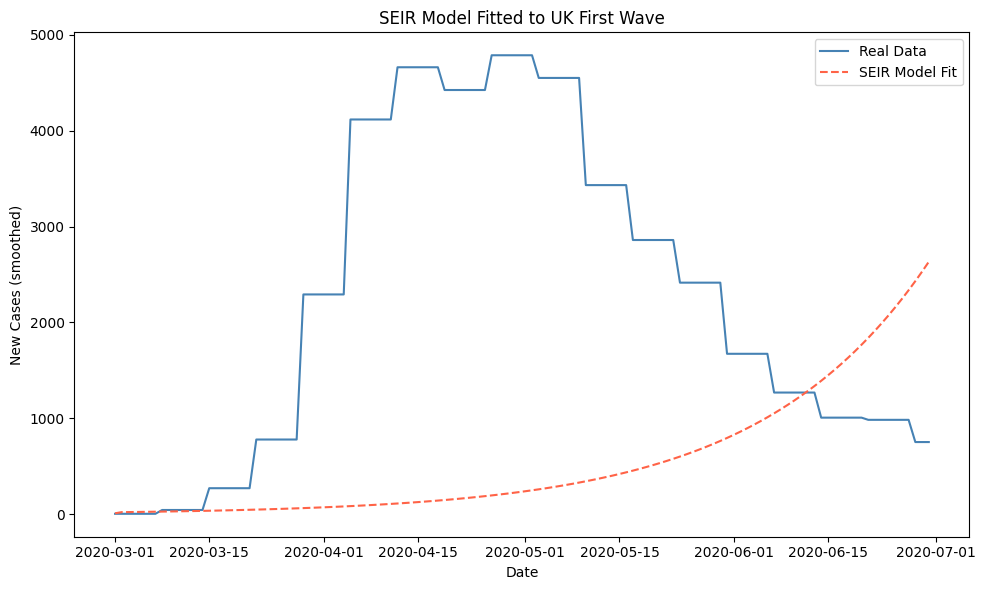

In [23]:
fitted_cases = seir_for_fitting(t_fit, beta_fit, gamma_fit)

plt.figure(figsize=(10, 6))
plt.plot(wave1['date'], actual_cases, label='Real Data', color='steelblue')
plt.plot(wave1['date'], fitted_cases, label='SEIR Model Fit', color='tomato', linestyle='--')
plt.title('SEIR Model Fitted to UK First Wave')
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.legend()
plt.tight_layout()
plt.show()

### Model Fit Assessment

The SEIR model does not fit the UK first wave well — the model predicts 
continued exponential growth while the real data peaks and falls.

**Why the fit is poor:**
The model assumes a constant transmission rate β throughout the period.
In reality, the UK entered lockdown on 23rd March 2020 which dramatically 
reduced β overnight. The real epidemic peaked due to behavioural change,
not depletion of susceptibles.

**Key limitation:** Simple compartmental models cannot capture sudden 
policy interventions or behavioural changes without explicitly modelling 
them as time-varying parameters.

**What a better model would need:**
- A time-varying β(t) that drops when lockdown is imposed
- Or separate model phases for pre and post lockdown

In [26]:
N = 67000000
I0 = 10
E0 = 100
R0_init = 0
S0 = N - I0 - E0 - R0_init

t_fit = np.arange(len(wave1))
actual_cases = wave1['new_cases_smoothed'].values

def seir_two_phase(t, beta1, beta2, gamma):
    sigma = 0.2  # fixed incubation rate
    
    S, E, I, R = S0, E0, I0, R0_init
    new_cases = []
    
    for day, _ in enumerate(t):

        lockdown_day = 22

        if day < lockdown_day:
            beta = beta1
        else:
            beta = beta2

        new_infections = beta * S * I / N
        dS = -new_infections
        dE = new_infections - sigma * E
        dI = sigma * E - gamma * I
        dR = gamma * I
        
        S += dS
        E += dE
        I += dI
        R += dR
        
        new_cases.append(new_infections)
    
    return np.array(new_cases)

# Fit the model
params, _ = curve_fit(seir_two_phase, t_fit, actual_cases, 
                       p0=[0.4, 0.1, 0.1],  # initial guesses
                       bounds=([0, 0, 0], [1, 1, 1]))  # parameter bounds

beta1_fit, beta2_fit, gamma_fit = params
print(f'Fitted beta1 (pre-lockdown): {beta1_fit:.4f}')
print(f'Fitted beta2 (post-lockdown): {beta2_fit:.4f}')
print(f'Fitted gamma: {gamma_fit:.4f}')
print(f'Fitted R0 pre-lockdown: {beta1_fit/gamma_fit:.2f}')
print(f'Fitted R0 post-lockdown: {beta2_fit/gamma_fit:.2f}')

Fitted beta1 (pre-lockdown): 1.0000
Fitted beta2 (post-lockdown): 0.1398
Fitted gamma: 0.1321
Fitted R0 pre-lockdown: 7.57
Fitted R0 post-lockdown: 1.06


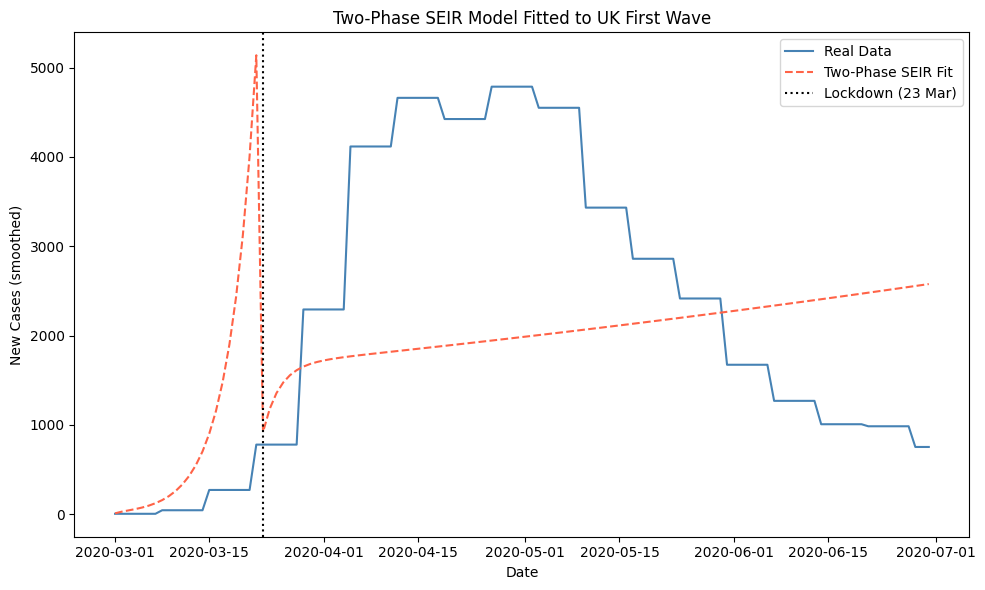

In [27]:
fitted_cases_two_phase = seir_two_phase(t_fit, beta1_fit, beta2_fit, gamma_fit)

plt.figure(figsize=(10, 6))
plt.plot(wave1['date'], actual_cases, label='Real Data', color='steelblue')
plt.plot(wave1['date'], fitted_cases_two_phase, label='Two-Phase SEIR Fit', color='tomato', linestyle='--')
plt.axvline(x=wave1['date'].iloc[22], color='black', linestyle=':', label='Lockdown (23 Mar)')
plt.title('Two-Phase SEIR Model Fitted to UK First Wave')
plt.xlabel('Date')
plt.ylabel('New Cases (smoothed)')
plt.legend()
plt.tight_layout()
plt.show()

### Two-Phase Model Assessment

The two-phase model improves on the single-phase model by correctly capturing 
the change in transmission at lockdown. However, significant limitations remain:

1. **Pre-lockdown data is sparse** (only 22 days) making β₁ unreliable
2. **The model still grows post-lockdown** (R0=1.06 > 1) while real cases fell
3. **Real behaviour is more complex** — compliance with lockdown increased 
   gradually, not instantaneously on 23rd March

**Key insight:** Even simple two-phase models struggle to capture real epidemic 
dynamics. Real epidemiological models use time-varying β(t) estimated from 
mobility data, policy records, and behavioural surveys.

This limitation is not a failure — it shows the boundary of what simple 
compartmental models can and cannot do.